In [331]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import sys, os


sys.path.append(os.path.abspath(".."))
from data_cleaning import *


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [332]:
data = filter_data()
print(data.keys())

features_all = ["age", "priors_count", "sex", "race","juv_fel_count","juv_misd_count","juv_other_count","c_charge_degree"]
features_no_demo = ["priors_count","juv_fel_count","juv_misd_count","juv_other_count","c_charge_degree"]

X_all = data[features_all].to_numpy()
X_no_demo = data[features_no_demo].to_numpy()

y = data["two_year_recid"].to_numpy()

group = data["race"].to_numpy()

print(X_all.shape)
print(X_no_demo.shape)
print(y.shape)
print(group.shape)

print(np.unique(group))

Index(['sex', 'age', 'age_cat', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'c_charge_degree', 'c_charge_desc',
       'type_of_assessment', 'two_year_recid'],
      dtype='object')
(7214, 8)
(7214, 5)
(7214,)
(7214,)
['African-American' 'Asian' 'Caucasian' 'Hispanic' 'Native American'
 'Other']


In [333]:
from sklearn.preprocessing import OneHotEncoder

non_numeric_features = X_all[:, 2: ]

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc_no_demo = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_array_all = enc.fit_transform(non_numeric_features)
encoded_array_no_demo = enc_no_demo.fit_transform(X_no_demo[:, 2: ])

features_processed_all = np.hstack((X_all[:, :2], encoded_array_all))
features_processed_no_demo = np.hstack((X_no_demo[:, :2], encoded_array_no_demo,))

features_processed_all


array([[69, 0, 0.0, ..., 0.0, 1.0, 0.0],
       [34, 0, 0.0, ..., 0.0, 1.0, 0.0],
       [24, 4, 0.0, ..., 0.0, 1.0, 0.0],
       ...,
       [57, 0, 0.0, ..., 0.0, 1.0, 0.0],
       [33, 3, 1.0, ..., 0.0, 0.0, 1.0],
       [23, 2, 1.0, ..., 0.0, 1.0, 0.0]], shape=(7214, 43), dtype=object)

In [334]:
from sklearn.model_selection import train_test_split

X_tr, X_te, X_tr_no_demo, X_te_no_demo, y_tr, y_te, gr_tr, gr_te = train_test_split(features_processed_all, features_processed_no_demo, y, group, test_size = 0.2, random_state=42)

In [335]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

X_tr_no_demo = scaler.fit_transform(X_tr_no_demo)
X_te_no_demo = scaler.transform(X_te_no_demo)

In [336]:
from sklearn.linear_model import LogisticRegression

model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_tr, y_tr)
preds = model_all.predict(X_te)


model_no_demo = LogisticRegression(max_iter=1000)
model_no_demo.fit(X_tr_no_demo, y_tr)
preds_no_demo = model_no_demo.predict(X_te_no_demo)

In [337]:
def get_accuracy(y_true, y_pred):
    ''' Return the accuracy (fraction of predictiosn that are correct)
        y_true = ground truth labels
        y_pred = model's predictions of the labels
    '''
    num_accurate = 0
    total_labels = y_true.shape[0]
    for i in range(total_labels):
        if y_true[i] == y_pred[i]:
            num_accurate += 1
    return num_accurate/total_labels

def get_precision(y_true, y_pred):
    ''' Return the precision (fraction of positive predictions that are correct)
        y_true = ground truth labels
        y_pred = model's predictions of the labels
    '''
    num_precise = 0
    total_labels = y_true.shape[0]
    total_positive_preds = 0

    for i in range(total_labels):
        if y_pred[i] == True:
            total_positive_preds += 1
            if (y_true[i] == y_pred[i]):
                num_precise += 1
    if total_positive_preds == 0:
        return 0
    return num_precise/total_positive_preds

def get_recall(y_true, y_pred):
    ''' Return the recall (fraction of actual positive examples that are correctly predicted)
        y_true = ground truth labels
        y_pred = model's predictions of the labels
    '''

    num_recall = 0
    total_labels = y_true.shape[0]
    total_positive_true = 0

    for i in range(total_labels):
        if y_true[i] == True:
            total_positive_true += 1
            if (y_true[i] == y_pred[i]):
                num_recall += 1
    if total_positive_true == 0:
        return 0
    return num_recall/total_positive_true

In [338]:
accuracy = get_accuracy(y_te, preds)
precision = get_precision(y_te, preds)
recall = get_recall(y_te, preds)

accuracy_no_demo = get_accuracy(y_te, preds_no_demo)
precision_no_demo = get_precision(y_te, preds_no_demo)
recall_no_demo = get_recall(y_te, preds_no_demo)

print("Accuracy when including demographical features:" , accuracy)
print("Accuracy when omitting demographical features:", accuracy_no_demo)
print()
print("Precision when including demographical features:",precision)
print("Precision when omitting demographical features:",precision_no_demo)
print()
print("Recall when including demographical features", recall)
print("Recall when including demographical features", recall_no_demo)

Accuracy when including demographical features: 0.6860706860706861
Accuracy when omitting demographical features: 0.6666666666666666

Precision when including demographical features: 0.6596558317399618
Precision when omitting demographical features: 0.6612529002320185

Recall when including demographical features 0.5564516129032258
Recall when including demographical features 0.4596774193548387


In [339]:
model_all.coef_

model_no_demo.coef_


array([[ 0.55447533,  0.17239123, -0.07213167,  0.0303773 ,  0.06359535,
         0.00546375, -0.0032686 ,  0.10799034, -0.0703958 ,  0.09498986,
         0.03715255,  0.0380653 , -0.1177535 ,  0.11552968, -0.01769644,
         0.08237083,  0.01536066,  0.01495675,  0.05708677, -0.09469809,
         0.08328553,  0.        ,  0.07290005, -0.07290005]])

In [351]:
gr_te_unique, gr_te_counts = np.unique(gr_te, return_counts=True)
print(gr_te_unique)

['African-American' 'Asian' 'Caucasian' 'Hispanic' 'Native American'
 'Other']


In [341]:
# This loop prints summary statistics by racial group
for g_idx in range(len(gr_te_unique)):
    gr_label = gr_te_unique[g_idx]   
    group_name = gr_label

    idx = (gr_te == gr_label) # indices of data belonging to this group
    
    # filter to only include data from this group
    new_features = X_te[idx]
    new_features_no_demo = X_te_no_demo[idx]
    new_labels = y_te[idx]

    new_preds_all = model_all.predict(new_features)
    new_preds_no_demo = model_no_demo.predict(new_features_no_demo)

    acc_all = get_accuracy(new_labels, new_preds_all)
    prec_all = get_precision(new_labels, new_preds_all)
    rec_all = get_recall(new_labels, new_preds_all)

    acc_no_demo = get_accuracy(new_labels, new_preds_no_demo)
    prec_no_demo = get_precision(new_labels, new_preds_no_demo)
    rec_no_demo = get_recall(new_labels, new_preds_no_demo)
    
    print("With demographics:")
    print(f"Statistics for group: {group_name} (count: {len(new_features)})")
    print(f"Accuracy: {acc_all:.4f}, Precision: {prec_all:.4f}, Recall: {rec_all:.4f}")
    print()
    print("Without demographics:")
    print(f"Statistics for group: {group_name} (count: {len(new_features)})")
    print(f"Accuracy: {acc_no_demo:.4f}, Precision: {prec_no_demo:.4f}, Recall: {rec_no_demo:.4f}")
    print()


With demographics:
Statistics for group: African-American (count: 731)
Accuracy: 0.6895, Precision: 0.7008, Recall: 0.6801

Without demographics:
Statistics for group: African-American (count: 731)
Accuracy: 0.6443, Precision: 0.7059, Recall: 0.5161

With demographics:
Statistics for group: Asian (count: 5)
Accuracy: 0.6000, Precision: 0.0000, Recall: 0.0000

Without demographics:
Statistics for group: Asian (count: 5)
Accuracy: 0.8000, Precision: 0.5000, Recall: 1.0000

With demographics:
Statistics for group: Caucasian (count: 505)
Accuracy: 0.6832, Precision: 0.5940, Recall: 0.4270

Without demographics:
Statistics for group: Caucasian (count: 505)
Accuracy: 0.6950, Precision: 0.6281, Recall: 0.4108

With demographics:
Statistics for group: Hispanic (count: 117)
Accuracy: 0.7094, Precision: 0.5000, Recall: 0.2353

Without demographics:
Statistics for group: Hispanic (count: 117)
Accuracy: 0.6838, Precision: 0.4286, Recall: 0.2647

With demographics:
Statistics for group: Native Amer

In [342]:
def get_demographic_parity(y_true, y_pred, group):
    ''' Return the demographic parity difference
        y_true = ground truth labels
        y_pred = model's predictions of the labels
        group = demographic group labels for each example
    '''
    total_majority_g = 0
    total_minority_g = 0

    total_majority_pos = 0
    total_minority_pos = 0
    for i in range(y_true.shape[0]):
        if group[i] == "Caucasian": # white demographic
            total_majority_g += 1
            if y_pred[i]:
                total_majority_pos +=1
        if group[i] == "African-American": # black demographic
            total_minority_g += 1
            if y_pred[i]:
                total_minority_pos +=1

    prob_majority_pos = total_majority_pos / total_majority_g
    prob_minority_pos = total_minority_pos / total_minority_g
    return prob_majority_pos / prob_minority_pos


train_dp = get_demographic_parity(y_tr, model_all.predict(X_tr), gr_tr)
test_dp = get_demographic_parity(y_te, model_all.predict(X_te), gr_te)

train_dp_no_demo = get_demographic_parity(y_tr, model_no_demo.predict(X_tr_no_demo), gr_tr)
test_dp_no_demo = get_demographic_parity(y_te, model_no_demo.predict(X_te_no_demo), gr_tr)

print("Demographic Parity (train): ", train_dp)
print("Demographic Parity (test): ", test_dp)
print()
print("Demographic Parity Without Demographics(train): ", train_dp_no_demo)
print("Demographic Parity Without Demographics(test): ", test_dp_no_demo)

Demographic Parity (train):  0.5223781048840744
Demographic Parity (test):  0.5332985930171965

Demographic Parity Without Demographics(train):  0.5450842142503886
Demographic Parity Without Demographics(test):  1.0668276972624797


In [343]:
from sklearn.metrics import confusion_matrix
def get_equalized_odds(y_true, y_pred, group):
    unique_group = np.unique(group)
    tpr, fpr = [] , []
    
    for g in unique_group:
        g_idx = (group == g)
        g_labels = y_true[g_idx]
        g_preds = y_pred[g_idx]
        
        tn, fp, fn, tp = confusion_matrix(g_labels, g_preds, labels = [0,1]).ravel()
        tpr.append(tp / (tp + fn))  
        fpr.append(fp / (fp + tn))
    return np.allclose(tpr, tpr[0]) and np.allclose(fpr, fpr[0])

train_eo = get_equalized_odds(y_tr, model_all.predict(X_tr), gr_tr)
test_eo = get_equalized_odds(y_te, model_all.predict(X_te), gr_te)

train_eo_no_demo = get_equalized_odds(y_tr, model_no_demo.predict(X_tr_no_demo), gr_tr)
test_eo_no_demo = get_equalized_odds(y_te, model_no_demo.predict(X_te_no_demo), gr_te)

print("Equalized Odds (train)", train_eo)
print("Equalized Odds (test)", test_eo)
print()
print("Equalized Odds (train)", train_eo_no_demo)
print("Equalized Odds (test)", test_eo_no_demo)

Equalized Odds (train) False
Equalized Odds (test) False

Equalized Odds (train) False
Equalized Odds (test) False


In [344]:
def preds_with_cutoffs(X, group, cutoff):
    ''' Used as part of our post-processing approach to fairness.
       Return predictions with group-specific cutoffs
        X = input features
        group = group membership for each example
        cutoff = two options for how to use this parameter:
            1) [Recommended] if cutoff is a single float value, use this value for certain group(s) and 0.5 for others.
                You can hardcode which groups get which cutoff in this case.
            2) if cutoff is a dictionary mapping group labels to cutoff values, use the specified cutoff for each group.    
    '''

    y_probs = model_all.predict_proba(X)
    preds = []
    for i in range(y_probs.shape[0]):
        if group[i] == 1:
            threshold = 0.5
        else:
            threshold = cutoff
        if y_probs[i][1] >= threshold:
            preds.append(1)
        else:
            preds.append(0)

    return preds


In [345]:
cutoff_vals = [0.3, 0.35, 0.4, 0.45, 0.5] # list possible cutoff values here

for cutoff in cutoff_vals:

    print("Cutoff value:", cutoff)
    # Training
    # compute the new predictions using preds_with_cutoffs
    print("Training")
    y_preds = preds_with_cutoffs(X_tr, gr_tr, cutoff)
    # compute the accuracy and demographic parity using these new predictions
    parity = get_demographic_parity(y_tr, y_preds, gr_tr)
    print("Parity", parity)
    accuracy = get_accuracy(y_tr, y_preds)
    print("accuracy", accuracy)
    
    # Testing
    print("Testing")
    y_preds = preds_with_cutoffs(X_te, gr_te, cutoff)
    # compute the accuracy and demographic parity using these new predictions
    parity = get_demographic_parity(y_te, y_preds, gr_te)
    print("Parity", parity)
    accuracy = get_accuracy(y_te, y_preds)
    print("accuracy", accuracy)
    print()
    


Cutoff value: 0.3
Training
Parity 0.7768058947781478
accuracy 0.57875584820655
Testing
Parity 0.8181661644425311
accuracy 0.5502425502425502

Cutoff value: 0.35
Training
Parity 0.7225056302196009
accuracy 0.6087333217813204
Testing
Parity 0.7687694483734088
accuracy 0.6008316008316008

Cutoff value: 0.4
Training
Parity 0.6617345797694695
accuracy 0.6390573557442384
Testing
Parity 0.6800635157855408
accuracy 0.6410256410256411

Cutoff value: 0.45
Training
Parity 0.5914277738725158
accuracy 0.6634898631086467
Testing
Parity 0.5980981394842781
accuracy 0.6735966735966736

Cutoff value: 0.5
Training
Parity 0.5223781048840744
accuracy 0.6735401143649281
Testing
Parity 0.5332985930171965
accuracy 0.6860706860706861



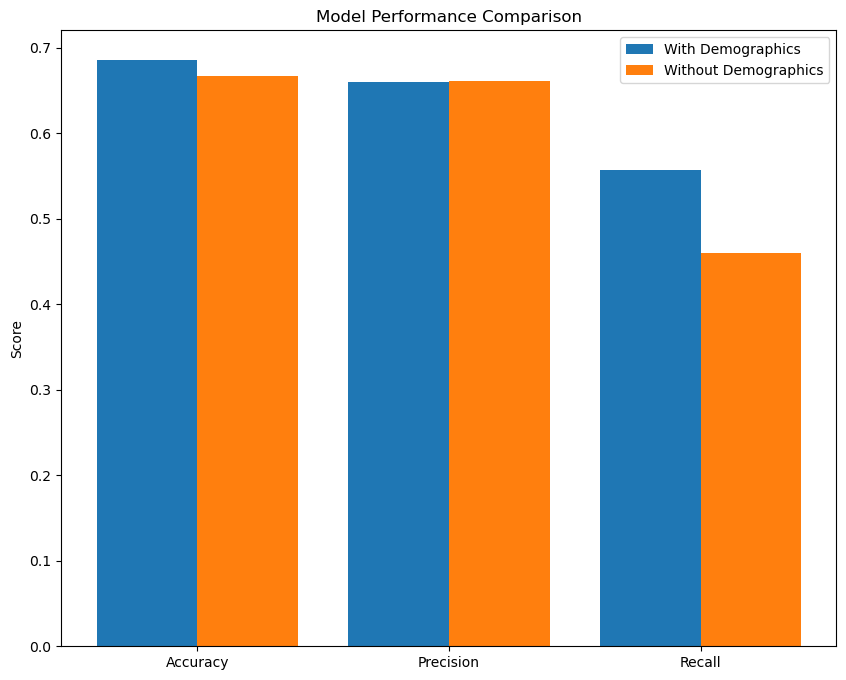

In [346]:
metrics_all = [accuracy, precision, recall]
metrics_no_demo = [accuracy_no_demo, precision_no_demo, recall_no_demo]

labels = ["Accuracy", "Precision", "Recall"]
x = np.arange(len(labels))

plt.bar(x - 0.2, metrics_all, width=0.4, label="With Demographics")
plt.bar(x + 0.2, metrics_no_demo, width=0.4, label="Without Demographics")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

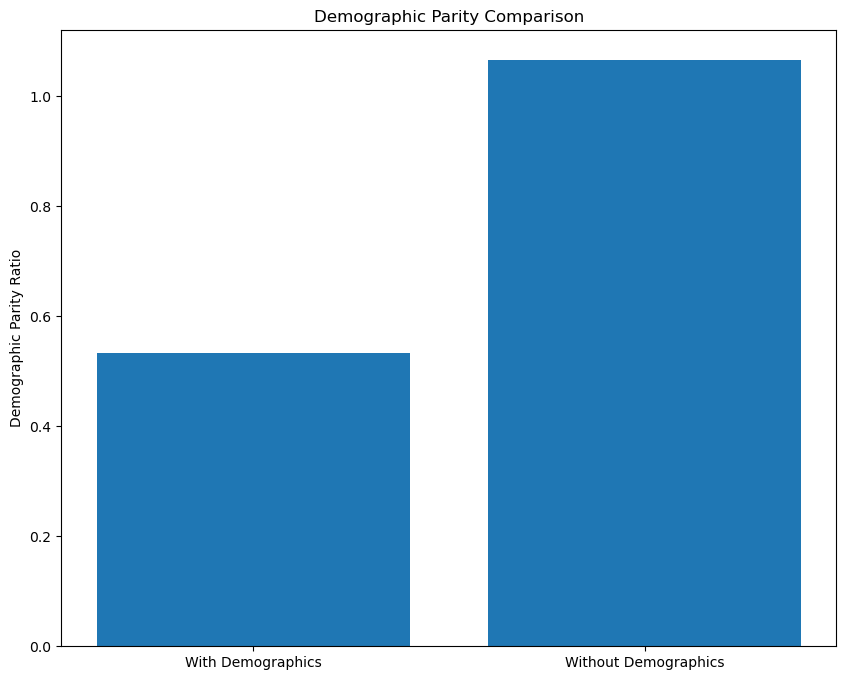

In [347]:
dp_values = [test_dp, test_dp_no_demo]
labels = ["With Demographics", "Without Demographics"]

plt.bar(labels, dp_values)

plt.ylabel("Demographic Parity Ratio")
plt.title("Demographic Parity Comparison")

plt.show()

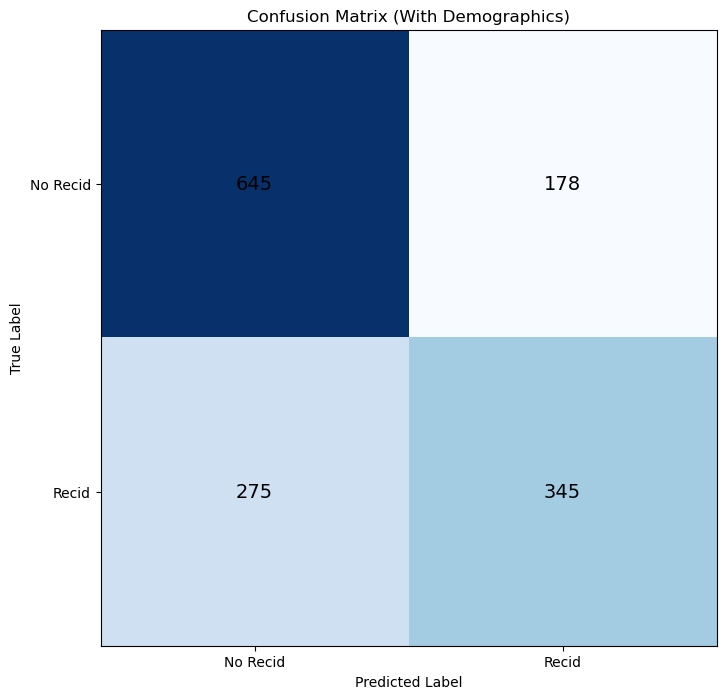

In [348]:
cm_all = confusion_matrix(y_te, preds)

plt.figure()

plt.imshow(cm_all, cmap="Blues")

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (With Demographics)")

# Tick labels
plt.xticks([0,1], ["No Recid", "Recid"])
plt.yticks([0,1], ["No Recid", "Recid"])

# Add numbers inside boxes
for i in range(cm_all.shape[0]):
    for j in range(cm_all.shape[1]):
        plt.text(j, i, cm_all[i, j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=14)

plt.show()

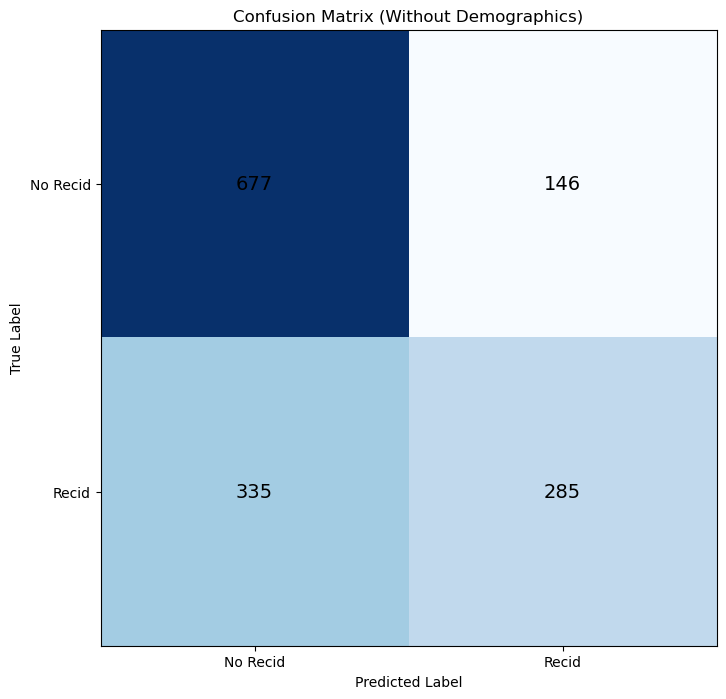

In [349]:
cm_no_demo = confusion_matrix(y_te, preds_no_demo)

plt.figure()

plt.imshow(cm_no_demo, cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Without Demographics)")

plt.xticks([0,1], ["No Recid", "Recid"])
plt.yticks([0,1], ["No Recid", "Recid"])

for i in range(cm_no_demo.shape[0]):
    for j in range(cm_no_demo.shape[1]):
        plt.text(j, i, cm_no_demo[i, j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=14)

plt.show()